In [1]:
# Output:
# 1) Stratified CV F1_macro
# 2) GroupKFold by region F1_macro
# 3) Holdout metrics + confusion matrix
# 4) Permutation importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

C:\Users\Zepspel\AppData\Local\Temp\ipykernel_5944\3320810376.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(CSV_PATH)


Classes: ['control', 'endo', 'exo']
Samples: 62475 | Spectrum points: 1015 | Unique regions: 7
Feature matrix: (62475, 1178)

Holdout (stratified) metrics:
Accuracy: 0.780524
F1 macro: 0.778439
              precision    recall  f1-score   support

     control       0.77      0.76      0.76      5250
        endo       0.77      0.73      0.75      4856
         exo       0.80      0.84      0.82      5513

    accuracy                           0.78     15619
   macro avg       0.78      0.78      0.78     15619
weighted avg       0.78      0.78      0.78     15619



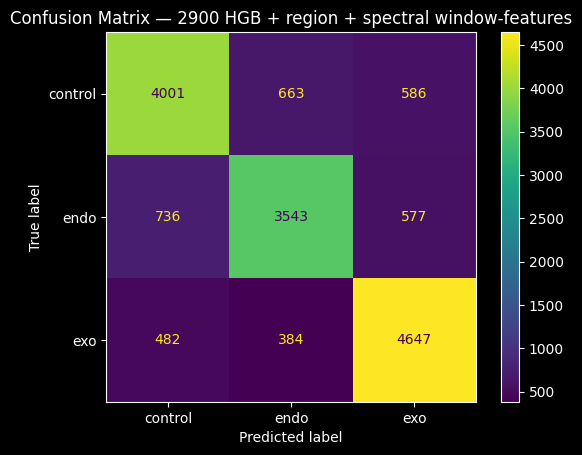

Permutation importance:


PicklingError: Could not pickle the task to send it to the workers.

In [2]:


# -------------------- 0) PATH --------------------
CSV_PATH = "mergedData/data_feat_2900_std.csv"

# -------------------- 1) LOAD --------------------
df0 = pd.read_csv(CSV_PATH)


wave_cols = [c for c in df0.columns if str(c).startswith("Wave_")]

def parse_wave(c):
    return float(str(c).split("_", 1)[1])

wave_axis = np.array([parse_wave(c) for c in wave_cols], dtype=float)
order = np.argsort(wave_axis)
wave_axis = wave_axis[order]
wave_cols = [wave_cols[i] for i in order]

df = df0
for c in wave_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["position", "class"] + wave_cols).reset_index(drop=True)

Xmat = df[wave_cols].to_numpy(dtype=float)
if not np.isfinite(Xmat).all():
    raise ValueError("В интенсивностях есть NaN/inf — сначала почистите данные.")

region = df["position"].astype(str).to_numpy()
y_str = df["class"].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)

print("Classes:", list(le.classes_))
print("Samples:", len(df), "| Spectrum points:", Xmat.shape[1], "| Unique regions:", len(np.unique(region)))

# -------------------- 2) FEATURE ENGINEERING FOR 2900 --------------------

F = df.drop(["position","class","group","nm","center","obj","power","during","acc","map","step","place","X","Y"], axis=1)

X_all = pd.concat([pd.DataFrame({"region": region}), F.reset_index(drop=True)], axis=1)
feat_names = F.columns.tolist()

print("Feature matrix:", F.shape)

# -------------------- 3) MODEL --------------------
pre = ColumnTransformer(
    transformers=[
        ("region_ohe", OneHotEncoder(handle_unknown="ignore"), ["region"]),
        ("spec", "passthrough", feat_names),
    ],
    remainder="drop",
)

model = Pipeline([
    ("pre", pre),
    ("clf", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        #max_depth=10,
        #learning_rate=0.02,
        max_iter=400,
        random_state=42
    ))
])

# -------------------- 6) Holdout --------------------
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.25, random_state=42, stratify=y)

model.fit(X_tr, y_tr)
pred = model.predict(X_te)

acc = accuracy_score(y_te, pred)
f1m = f1_score(y_te, pred, average="macro")
print("\nHoldout (stratified) metrics:")
print("Accuracy:", f"{acc:.6f}")
print("F1 macro:", f"{f1m:.6f}")
print(classification_report(y_te, pred, target_names=le.classes_))

cm = confusion_matrix(y_te, pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()
plt.title("Confusion Matrix — 2900 HGB + region + spectral window-features")
plt.show()

# -------------------- 7) Permutation importance --------------------
print("Permutation importance:")

perm = permutation_importance(
    model, X_te, y_te,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X_te.columns.to_list(),
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop-20 INPUT features by permutation importance:")
display(imp_df.head(20))

top = imp_df.head(20).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["importance_mean"])
plt.title("Permutation importance (top 20) — 2900")
plt.xlabel("Mean decrease in F1_macro after permutation")
plt.show()

In [3]:
import joblib

MODEL_PATH = "hgb_raman_pipeline_2900.joblib"

joblib.dump({
    "model": model,
    "label_encoder": le,
    "wave_cols": wave_cols
}, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: hgb_raman_pipeline_2900.joblib


In [4]:
from IPython.display import FileLink
FileLink("hgb_raman_pipeline_2900.joblib")

D:\hakaton\hgb_raman_pipeline_2900.joblib

In [5]:
import joblib

checkpoint = joblib.load("hgb_raman_pipeline_2900.joblib")

model2 = checkpoint["model"]
le = checkpoint["label_encoder"]
wave_cols = checkpoint["wave_cols"]